In [32]:
from BOBE.bo import BOBE
from BOBE.samplers import sample_GP_NUTS
from BOBE.utils.flow import FlowTransform
from getdist import loadMCSamples, plots, MCSamples
import jax
import numpy as np  

In [9]:
reference_samples = loadMCSamples(
    './cosmo_input/chains/Planck_DESIDr2_LCDM_MCMC',
    settings={'ignore_rows': 0.3, 'label': 'MCMC'}
)

In [10]:
seed=42
cobaya_input_file = './cosmo_input/LCDM_Planck_DESI.yaml'
likelihood_name = f'Planck_DESI_LCDM_rotation_flowdiag_{seed}'

bobe = BOBE(
    loglikelihood=cobaya_input_file,
    likelihood_name=likelihood_name,
    confidence_for_unbounded=0.9999995,
    resume=True,
    resume_file=f'./results/LCDM/{likelihood_name}',
    save_dir='./results/LCDM/',
    save=False,
    verbosity='INFO',
    n_cobaya_init=4,
    n_sobol_init=32,
    optimizer='scipy',
    gp_kwargs={'lengthscale_prior': None, 'lengthscale_bounds': [1e-2, 4.]},
    use_clf=True,
    clf_type='svm',
    seed=seed,
    # No use_flow_transform — use the default rotation-based approach.
)

[0: model] WARNING: Ignored blocks/options: ['sampler', 'output']


[0: camb] INFO: `camb` module loaded successfully from /opt/homebrew/Caskroom/miniforge/base/envs/lisaet/lib/python3.12/site-packages/camb
[0: planck_npipe_highl_camspec.ttteee] INFO: L-range for 143x143: 30 2000
[0: planck_npipe_highl_camspec.ttteee] INFO: L-range for 217x217: 500 2500
[0: planck_npipe_highl_camspec.ttteee] INFO: L-range for 143x217: 500 2500
[0: planck_npipe_highl_camspec.ttteee] INFO: L-range for TE: 30 2000
[0: planck_npipe_highl_camspec.ttteee] INFO: L-range for EE: 30 2000
[0: planck_npipe_highl_camspec.ttteee] INFO: Number of data points: 9915
[0: bao.desi_dr2.desi_bao_all] INFO: Initialized.


[0: prior] WARNING: There are unbounded parameters (['calTE', 'A_planck', 'calEE']). Prior bounds are given at 0.9999995 confidence level. Beware of likelihood modes at the edge of the prior


[0: likelihood] INFO: Initialized Planck_DESI_LCDM_rotation_flowdiag_42 with 15 params
[0: likelihood] INFO: Param list: ['omch2', 'logA', 'ns', 'H0', 'ombh2', 'tau', 'A_planck', 'amp_143', 'amp_217', 'amp_143x217', 'n_143', 'n_217', 'n_143x217', 'calTE', 'calEE']
[0: likelihood] INFO: Param bounds: {'omch2': [0.11, 0.13], 'logA': [2.98, 3.1], 'ns': [0.94, 0.99], 'H0': [64, 72], 'ombh2': [0.021, 0.023], 'tau': [0.03, 0.08], 'A_planck': [0.987434, 1.01257], 'amp_143': [0, 50], 'amp_217': [0, 50], 'amp_143x217': [0, 50], 'n_143': [0, 5], 'n_217': [0, 5], 'n_143x217': [0, 5], 'calTE': [0.949737, 1.05026], 'calEE': [0.949737, 1.05026]}
[0: likelihood] INFO: Logprior volume = -7.8728
[0: transforms] INFO: Linear transform: ndim=15
[0: transforms] INFO: Physical bounds: [(np.float64(0.11), np.float64(0.13)), (np.float64(2.98), np.float64(3.1)), (np.float64(0.94), np.float64(0.99)), (np.float64(64.0), np.float64(72.0)), (np.float64(0.021), np.float64(0.023)), (np.float64(0.03), np.float64(0.0

In [22]:
gp_samples = sample_GP_NUTS(bobe.gp, num_samples = 10000, num_chains= 6, thinning=1)

In [23]:
print(gp_samples.keys())
samples = gp_samples['x']
print(samples.shape)
phys_samples = bobe.transform.from_unit(samples)
param_list = bobe.loglikelihood.param_list
param_bounds = bobe.loglikelihood.param_bounds
bobe_samples = MCSamples(samples=phys_samples, names=bobe.loglikelihood.param_list, 
                         labels=bobe.loglikelihood.param_labels,ranges= dict(zip(param_list,param_bounds.T)))


dict_keys(['x', 'logp', 'best', 'method'])
(60000, 15)


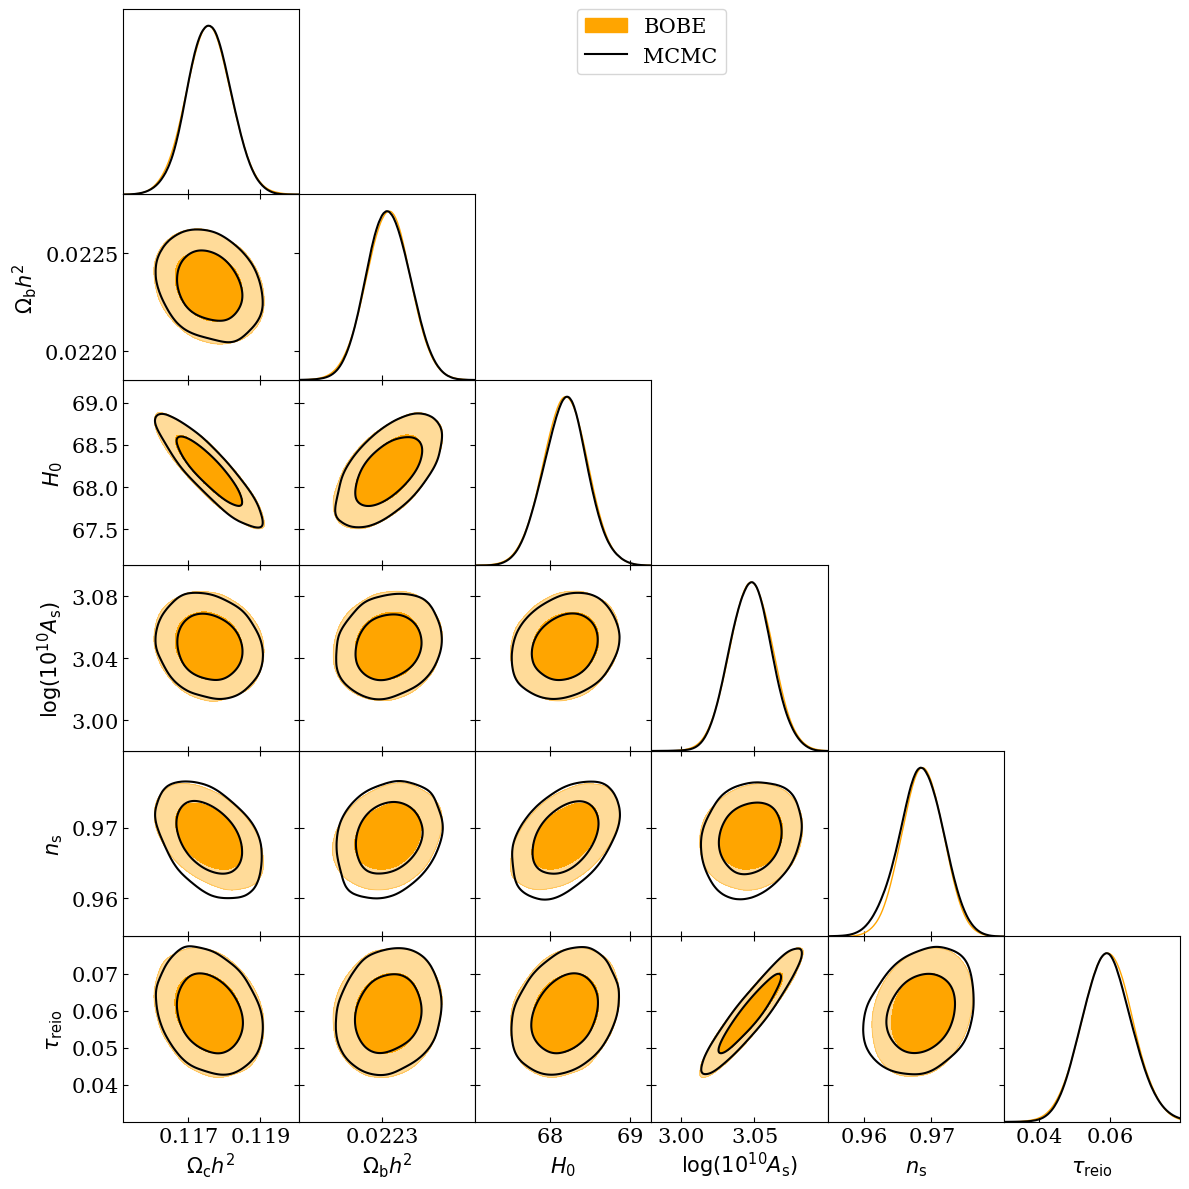

In [25]:
param_list_LCDM = ['omch2','ombh2','H0','logA','ns','tau']
g = plots.get_subplot_plotter(subplot_size=2, subplot_size_ratio=1)
g.settings.legend_fontsize = 18
g.settings.axes_fontsize = 18
g.settings.axes_labelsize = 18
g.triangle_plot([bobe_samples,reference_samples], filled=[True, False],
            contour_colors=['orange','black'], contour_lws=[1,1.5],
            params=param_list_LCDM,
            legend_labels=['BOBE','MCMC']) 


In [43]:
# train flow
flow = FlowTransform(param_bounds=param_bounds)
train_samples = phys_samples[::2]  # Use a subset of the samples for training
flow.train_flow(train_samples,
                flow_layers=8,
                nn_width=64,
                nn_depth=2,
                learning_rate=1e-3,
                max_epochs=600,
                batch_size=min(512, phys_samples.shape[0]),
                max_patience=40,)

[0: transforms] INFO: Linear transform: ndim=15
[0: transforms] INFO: Physical bounds: [(np.float64(0.11), np.float64(0.13)), (np.float64(2.98), np.float64(3.1)), (np.float64(0.94), np.float64(0.99)), (np.float64(64.0), np.float64(72.0)), (np.float64(0.021), np.float64(0.023)), (np.float64(0.03), np.float64(0.08)), (np.float64(0.9874342179098188), np.float64(1.0125657820900746)), (np.float64(0.0), np.float64(50.0)), (np.float64(0.0), np.float64(50.0)), (np.float64(0.0), np.float64(50.0)), (np.float64(0.0), np.float64(5.0)), (np.float64(0.0), np.float64(5.0)), (np.float64(0.0), np.float64(5.0)), (np.float64(0.9497368716392753), np.float64(1.0502631283602986)), (np.float64(0.9497368716392753), np.float64(1.0502631283602986))]
[0: flow_transform] INFO: Building coupling flow: D=15, layers=8, nn_width=64, nn_depth=2
[0: flow_transform] INFO: Training flow on 30000 samples …
[0: flow_transform] INFO: Flow trained for 301 epoch(s); final NLL train=-33.2259, val=-32.9684
[0: flow_transform] I

In [44]:
n_draw = 10_000
jkey = jax.random.key(1)
flow_samples_phys = np.asarray(flow._flow.sample(jkey, (n_draw,)))

gd_flow_samples = MCSamples(samples=flow_samples_phys, names=bobe.loglikelihood.param_list, 
                         labels=bobe.loglikelihood.param_labels,ranges= dict(zip(param_list,param_bounds.T)))


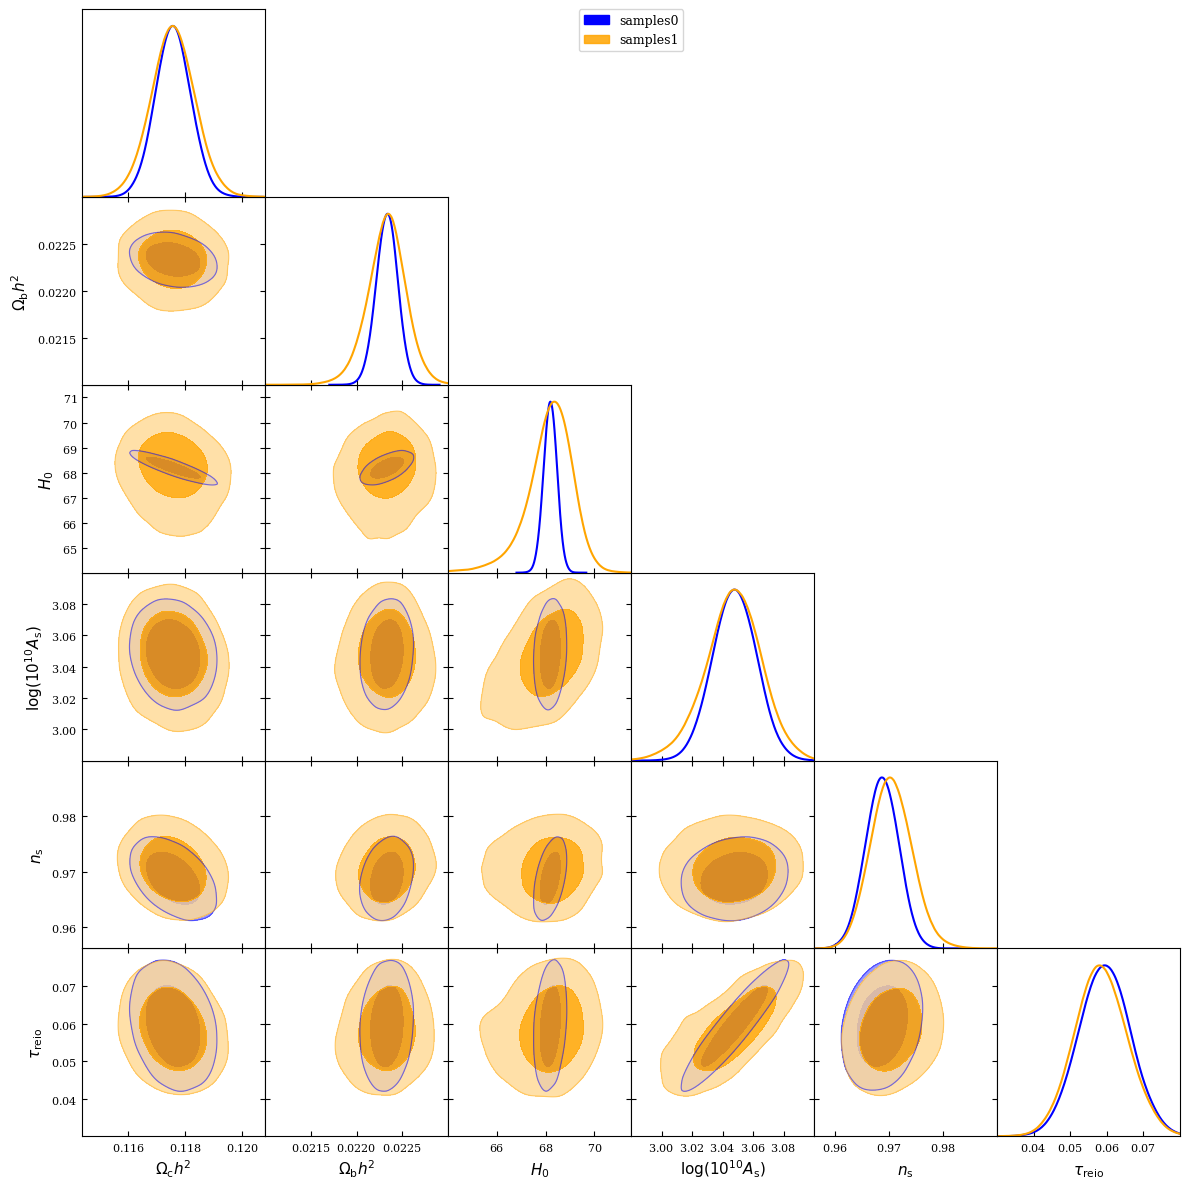

In [45]:
g = plots.get_subplot_plotter()
g.triangle_plot([bobe_samples,gd_flow_samples], filled=True, contour_colors=['blue','orange'], contour_lws=[1.5,1.5], 
                params=param_list_LCDM)

In [50]:
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal
from flowjax.train import fit_to_data
import jax.random as jr
import jax.numpy as jnp

key = jr.PRNGKey(42)
key, subkey = jr.split(key)

# Initialize a Masked Autoregressive Flow (MAF)
# Base distribution is a Standard Normal of the same dimension as our knots
base_dist = Normal(jnp.zeros(bobe.ndim))

train_mean = jnp.mean(phys_samples, axis=0)
train_std = jnp.std(phys_samples, axis=0)
train_samples = (phys_samples - train_mean) / train_std  # Standardize samples for

# We use a MAF with Rational Quadratic Spline transformers for high expressivity
# flow_layers=8 gives a deep enough flow to capture complex correlations
flow = masked_autoregressive_flow(
    key=subkey,
    base_dist=base_dist,
    flow_layers=8, 
    nn_width=64,
    nn_depth=2
)

# Train the flow using maximum likelihood
print("Fitting flow to posterior samples...")
key, subkey = jr.split(key)
flow, losses = fit_to_data(
    key=subkey,
    dist=flow,
    data=train_samples,
    learning_rate=1e-3,
    max_epochs=200,      # Usually converges quickly for this data size
    batch_size=256,
    show_progress=True
)


Fitting flow to posterior samples...


 12%|█▏        | 23/200 [00:17<02:14,  1.32it/s, train=11.9, val=12 (Max patience reached)]


In [51]:
n_draw = 10_000
jkey = jax.random.key(1)
flow_samples_phys = np.asarray(flow.sample(jkey, (n_draw,)))
flow_samples_phys = flow_samples_phys * train_std + train_mean  # Unstandardize samples

gd_flow_samples = MCSamples(samples=flow_samples_phys, names=bobe.loglikelihood.param_list, 
                         labels=bobe.loglikelihood.param_labels,ranges= dict(zip(param_list,param_bounds.T)))


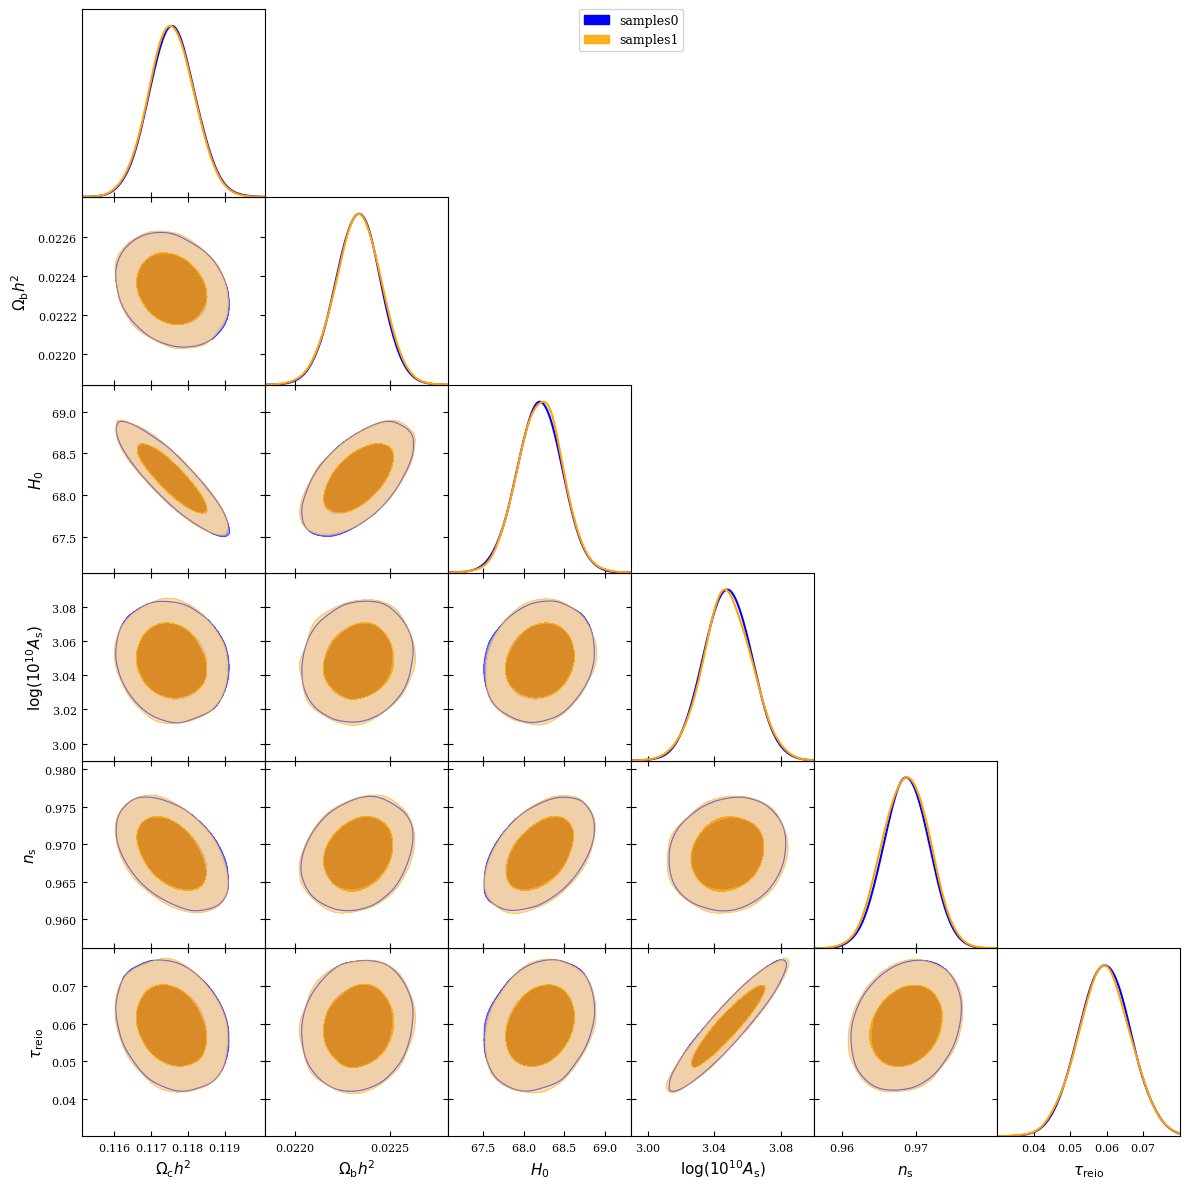

In [52]:
g = plots.get_subplot_plotter()
g.triangle_plot([bobe_samples,gd_flow_samples], filled=True, contour_colors=['blue','orange'], contour_lws=[1.5,1.5], 
                params=param_list_LCDM)